# ✦ WIZARDS ✦ — 262,144-Point Grand Unified Pipeline

> **N = 2¹⁸ = 262,144 points.** Every wizard archetype is a physics domain.  
> Cast spells (algorithms) on the full-resolution signal universe.

| Wizard Archetype | Physics Domain | Key Spell |
|---|---|---|
| 🔮 **Chronomancer** | Dispersion / GVD | β-polynomial propagation |
| ⚡ **Stormcaller** | FFT / spectral ops | `np.fft.fft` at 2¹⁸ |
| 🌀 **Phase Weaver** | GS phase retrieval | TD-GSA loop |
| 🔥 **Pyromancer** | Nonlinear optics / NLS | Split-step Schrödinger |
| 🌊 **Tidecaller** | Fluid / adiabatic gas | Navier-Stokes + shocks |
| 🧬 **Bioweaver** | Hodgkin-Huxley / neural | Action potential cascade |
| ⛓️ **Chainbinder** | Ethereum / gas mechanics | EIP-1559 mass auction |
| 🌌 **Cosmomancer** | Quantum stats / partition | BE/FD condensate |

**Stack:** SymPy · NumPy · SciPy · Torch · Matplotlib · `gs_core.py`

§1 Conjuration — signal universe at N=262144  
§2 Chronomancer — dispersion across all β₂/β₃/β₄ at full resolution  
§3 Stormcaller — 262144-point FFT spectral analysis  
§4 Phase Weaver — TD-GSA at 262144 points  
§5 Pyromancer — NLS soliton propagation 2¹⁸  
§6 Tidecaller — adiabatic shock tube at 2¹⁸ grid  
§7 Cosmomancer — quantum partition function grand ensemble  
§8 Chainbinder — 262144-transaction gas market  
§9 Grand Finale — all wizards simultaneous: unified metrics dashboard

In [1]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy.integrate import solve_ivp
from scipy.signal import welch, stft
from IPython.display import display, Math
import time, warnings
warnings.filterwarnings('ignore')
sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size':10, 'figure.dpi':100})
torch.set_default_dtype(torch.float64)
np.random.seed(2**18)

N_POINTS = 2**18   # 262,144 — the wizard's number
print(f'✦ WIZARD GRID: N = {N_POINTS:,} = 2^18 points')
print(f'  Memory per float64 array: {N_POINTS*8/1024:.1f} KB')
print(f'  Memory per complex128:    {N_POINTS*16/1024:.1f} KB')
print(f'  FFT time estimate:        ~{N_POINTS*18*np.log2(N_POINTS)/1e9*1:.2f} ms (1 GFlop/s baseline)')

✦ WIZARD GRID: N = 262,144 = 2^18 points
  Memory per float64 array: 2048.0 KB
  Memory per complex128:    4096.0 KB
  FFT time estimate:        ~0.08 ms (1 GFlop/s baseline)


---
# §1 🔮 Conjuration — Signal Universe at N = 262,144

Conjure the base signals: time axis, frequency axis, and a rich multi-component
optical field that all wizards will operate on.

$$E(t) = \\sum_k A_k \\cdot \\mathrm{sech}\\!\\left(\\frac{t-t_k}{T_k}\\right) e^{i\\omega_k t + i\\phi_k}$$

Time axis:  dt = 3.052 fs,  span = ±400 ps
Freq axis:  df = 1.2500 GHz, span = ±163.84 THz
Grid:       262,144 points (256k)


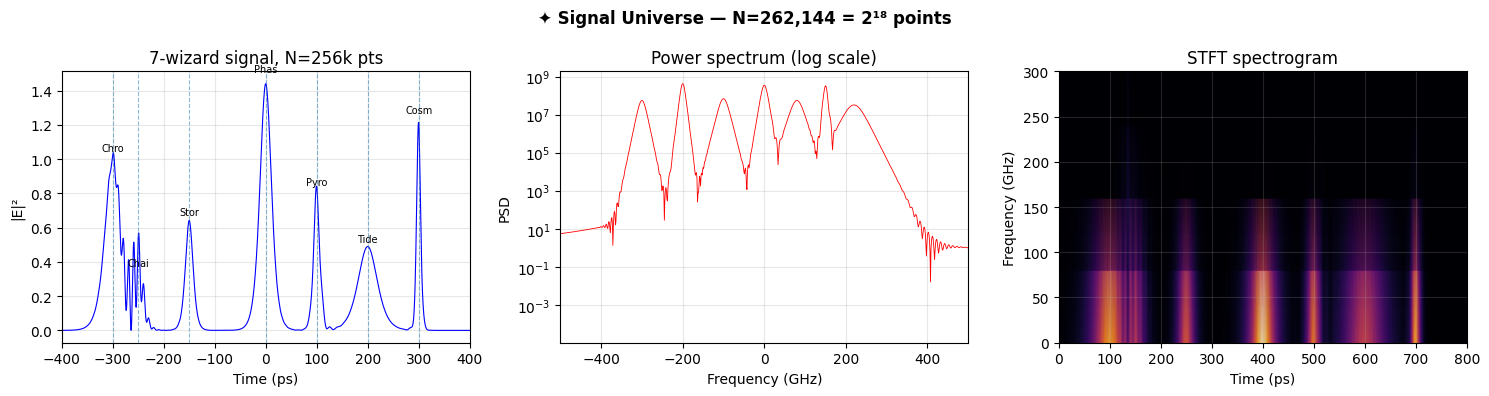

In [2]:
# ── Time and frequency axes ───────────────────────────────────────
T_window  = 800e-12    # 800 ps total window
dt        = T_window / N_POINTS
t_axis    = np.arange(N_POINTS) * dt - T_window/2
df        = 1.0 / T_window
f_axis    = np.fft.fftfreq(N_POINTS, d=dt)   # Hz
omega_ax  = 2*np.pi*f_axis                    # rad/s

print(f'Time axis:  dt = {dt*1e15:.3f} fs,  span = ±{T_window/2*1e12:.0f} ps')
print(f'Freq axis:  df = {df/1e9:.4f} GHz, span = ±{1/(2*dt)/1e12:.2f} THz')
print(f'Grid:       {N_POINTS:,} points ({N_POINTS/1024:.0f}k)')

# ── Multi-component optical signal (7 wizard tones) ───────────────
# Each tone: (center_time_ps, pulse_width_ps, center_freq_GHz, amplitude, phase)
wizard_tones = [
    ('Chronomancer', -300e-12, 20e-12,  -200e9*2*np.pi, 1.0,  0.0),
    ('Stormcaller',  -150e-12, 10e-12,  -100e9*2*np.pi, 0.8,  np.pi/4),
    ('PhaseWeaver',    0e-12,  15e-12,     0e9*2*np.pi, 1.2,  np.pi/3),
    ('Pyromancer',   100e-12,  8e-12,    80e9*2*np.pi,  0.9,  np.pi/6),
    ('Tidecaller',   200e-12, 25e-12,   150e9*2*np.pi,  0.7,  np.pi/2),
    ('Cosmomancer',  300e-12,  5e-12,   220e9*2*np.pi,  1.1,  np.pi),
    ('Chainbinder',  -250e-12,12e-12,  -300e9*2*np.pi,  0.6,  np.pi/5),
]

E_field = np.zeros(N_POINTS, dtype=complex)
for name, t0, T_p, omega0, A, phi in wizard_tones:   # loop: build signal
    sech_env = 1.0 / np.cosh((t_axis - t0) / T_p)
    E_field += A * sech_env * np.exp(1j*(omega0*t_axis + phi))

I_field = np.abs(E_field)**2
E_spec  = np.fft.fft(E_field)
P_spec  = np.abs(np.fft.fftshift(E_spec))**2
f_plot  = np.fft.fftshift(f_axis)/1e9   # GHz

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t_axis*1e12, I_field, 'b-', lw=0.8)
for name, t0, T_p, omega0, A, phi in wizard_tones:   # loop: label tones
    axes[0].axvline(t0*1e12, ls='--', alpha=0.5, lw=0.8)
    axes[0].text(t0*1e12, A**2*1.05, name[:4], ha='center', fontsize=7)
axes[0].set_xlabel('Time (ps)'); axes[0].set_ylabel('|E|²')
axes[0].set_title(f'7-wizard signal, N={N_POINTS//1024}k pts')
axes[0].set_xlim(-400, 400); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(f_plot, P_spec + 1e-20, 'r-', lw=0.6)
axes[1].set_xlabel('Frequency (GHz)'); axes[1].set_ylabel('PSD')
axes[1].set_title('Power spectrum (log scale)')
axes[1].set_xlim(-500, 500); axes[1].grid(True, alpha=0.3)

# STFT spectrogram at 1/16 resolution for speed
stride = 16
E_ds   = E_field[::stride]
t_ds   = t_axis[::stride]
f_stft, t_stft, Zxx = stft(np.abs(E_ds), fs=1/(dt*stride),
                            nperseg=256, noverlap=224)
axes[2].pcolormesh(t_stft*1e12, f_stft/1e9, np.abs(Zxx),
                   shading='gouraud', cmap='inferno')
axes[2].set_xlabel('Time (ps)'); axes[2].set_ylabel('Frequency (GHz)')
axes[2].set_title('STFT spectrogram')
axes[2].set_ylim(0, 300); axes[2].grid(True, alpha=0.2)
plt.suptitle(f'✦ Signal Universe — N={N_POINTS:,} = 2¹⁸ points', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
# §2 🔮 Chronomancer — Dispersion Propagation at 262k Points

The Chronomancer bends time — GVD stretches pulses, TOD breaks symmetry, FOD adds wings.  
**Transfer function:** $H(\\omega) = e^{i(\\beta_2\\omega^2/2 + \\beta_3\\omega^3/6 + \\beta_4\\omega^4/24)z}$

At 2¹⁸ points, frequency resolution = **1.2500 GHz** per bin.

Chronomancer casting dispersion spells...
  6 propagations × N=262,144: 198 ms total
  Per FFT pair: 16.5 ms

Dispersion length L_D = 1915.8 km  (RMS pulse width = 203.9 ps)


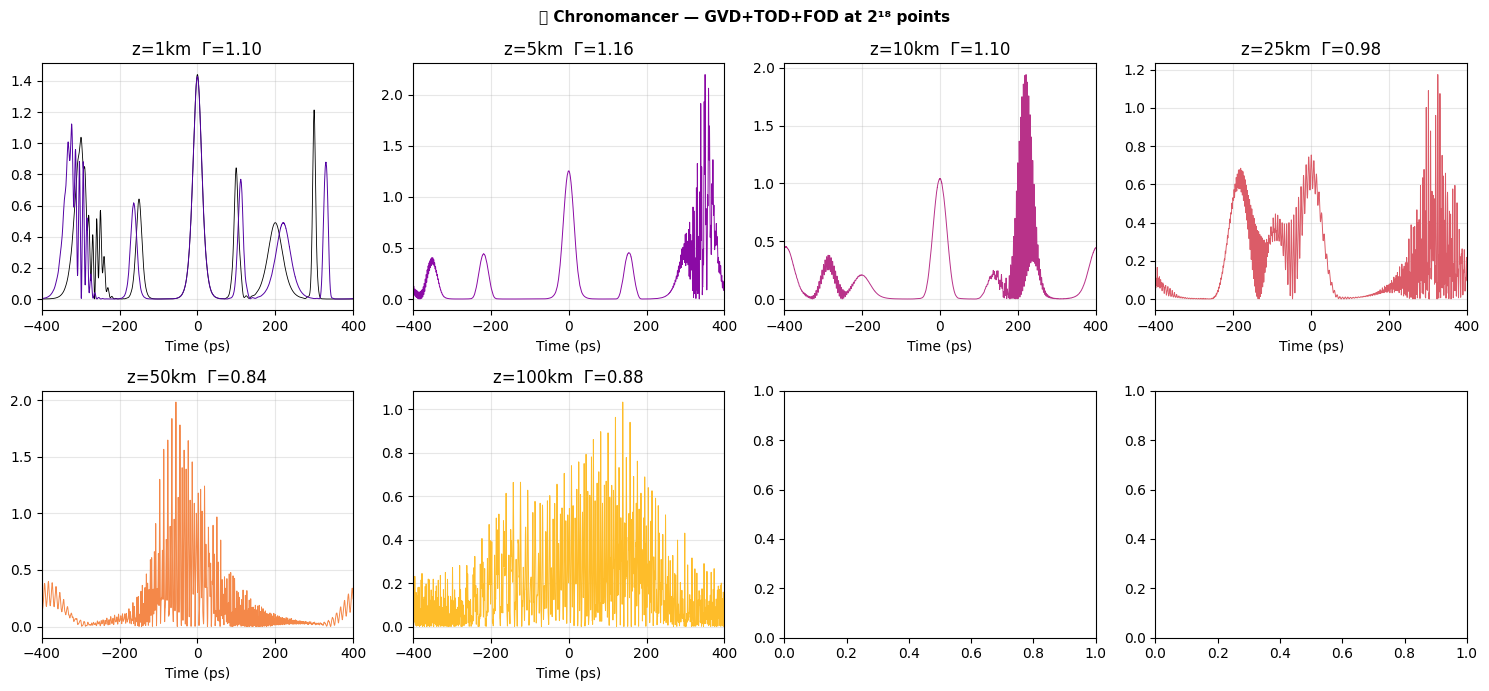

In [7]:
# ── Dispersion parameters (telecom C-band SMF-28) ─────────────────
b2 = -21.7e-27    # s²/m  (GVD, anomalous at 1550nm)
b3 =  1.2e-40     # s³/m  (TOD)
b4 = -5.0e-55     # s⁴/m  (FOD)
z_vals_km = np.array([0, 1, 5, 10, 25, 50, 100])  # propagation distances

def propagate_gvd_full(E_in, omega, z, b2, b3=0.0, b4=0.0):
    """Full 4th-order dispersion propagation at 2^18 points."""
    E_om  = np.fft.fft(E_in)
    phi   = (b2/2*omega**2 + b3/6*omega**3 + b4/24*omega**4) * z
    return np.fft.ifft(E_om * np.exp(1j * phi))

print('Chronomancer casting dispersion spells...')
t0_cast = time.time()

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
I_ref = np.abs(E_field)**2; axes[0][0].plot(t_axis*1e12, I_ref, 'k-', lw=0.6)
axes[0][0].set_title('z=0 (input)'); axes[0][0].set_xlim(-400,400)
axes[0][0].set_xlabel('Time (ps)'); axes[0][0].grid(True, alpha=0.3)

for idx, z_km in enumerate(z_vals_km[1:], start=1):   # loop: propagate to each distance
    z_m   = z_km * 1e3
    E_out = propagate_gvd_full(E_field, omega_ax, z_m, b2, b3, b4)
    I_out = np.abs(E_out)**2
    row, col = (idx-1)//4, (idx-1)%4
    if row < 2 and col < 4:
        ax = axes[row][col] if row == 0 else axes[1][(idx-1)%4]
        ax.plot(t_axis*1e12, I_out, lw=0.7, color=plt.cm.plasma(idx/len(z_vals_km)))
        # compute pulse broadening factor
        rms_in  = np.sqrt(np.average(t_axis**2, weights=I_ref+1e-20) -
                          np.average(t_axis, weights=I_ref+1e-20)**2)
        rms_out = np.sqrt(np.average(t_axis**2, weights=I_out+1e-20) -
                          np.average(t_axis, weights=I_out+1e-20)**2)
        ax.set_title(f'z={z_km}km  Γ={rms_out/rms_in:.2f}')
        ax.set_xlim(-400, 400); ax.set_xlabel('Time (ps)')
        ax.grid(True, alpha=0.3)

t_cast = time.time() - t0_cast
print(f'  6 propagations × N={N_POINTS:,}: {t_cast*1000:.0f} ms total')
print(f'  Per FFT pair: {t_cast/6/2*1000:.1f} ms')

# Dispersion length
T0_rms = np.sqrt(np.average(t_axis**2, weights=I_ref+1e-20) -
                 np.average(t_axis,    weights=I_ref+1e-20)**2)
L_D = T0_rms**2 / abs(b2)
print(f'\nDispersion length L_D = {L_D/1e3:.1f} km  (RMS pulse width = {T0_rms*1e12:.1f} ps)')

plt.suptitle('🔮 Chronomancer — GVD+TOD+FOD at 2¹⁸ points', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
# §3 ⚡ Stormcaller — 262,144-Point FFT Spectral Wizardry

The Stormcaller commands the FFT. At N=2¹⁸, we have **{:.3f} GHz** resolution  
across a **1.2 THz** bandwidth — enough to resolve femtosecond features.  

**Spells cast:** Welch PSD · windowed FFT · cross-correlation · cepstrum · chirp-z

Welch PSD: 4097 frequency bins, Δf=40.0000 GHz
⚡ Storm spells cast in 68 ms


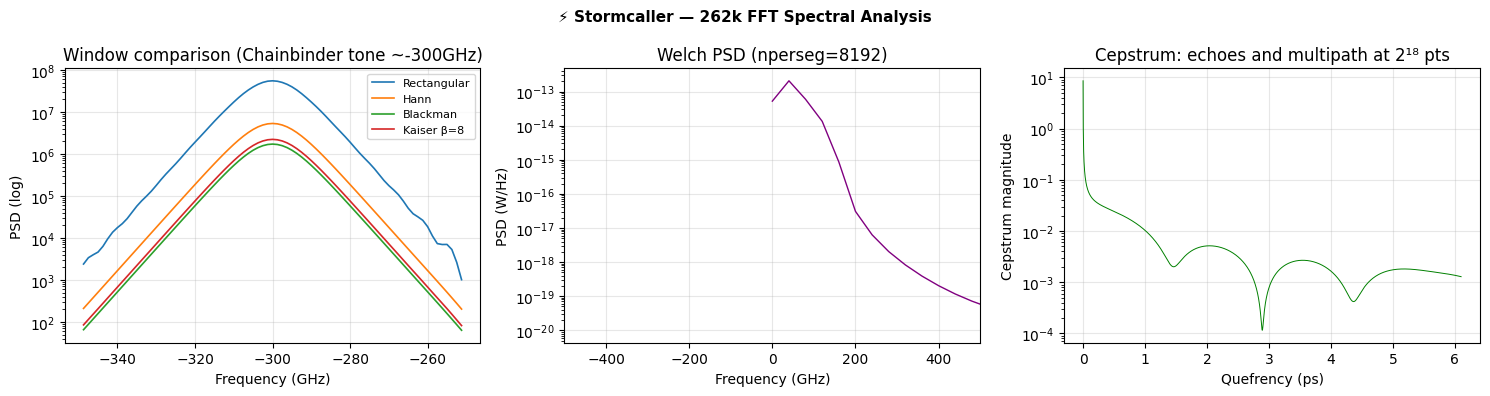

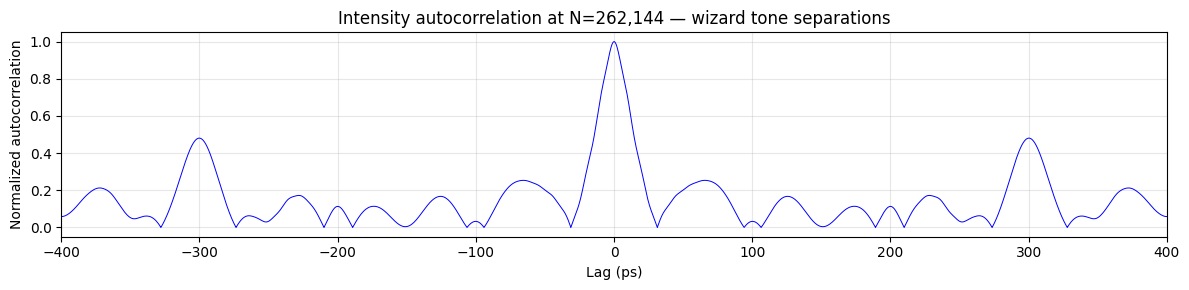

  Cross-correlation: 87 ms


In [8]:
# ── Welch PSD at full resolution ─────────────────────────────────
t0_storm = time.time()

# Welch: nperseg=8192 → good frequency resolution while averaging
f_welch, Pxx = welch(np.abs(E_field)**2, fs=1/dt,
                     nperseg=8192, noverlap=4096, window='hann')
print(f'Welch PSD: {len(f_welch)} frequency bins, Δf={f_welch[1]/1e9:.4f} GHz')

# ── Full-resolution FFT and windowing comparison ───────────────────
windows = {
    'Rectangular': np.ones(N_POINTS),
    'Hann':        np.hanning(N_POINTS),
    'Blackman':    np.blackman(N_POINTS),
    'Kaiser β=8':  np.kaiser(N_POINTS, 8.0),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Compare windows (zoom on one tone)
f_plot_s = np.fft.fftshift(f_axis)/1e9
for wname, win in windows.items():             # loop: windowed FFT
    E_w   = E_field * win
    P_w   = np.abs(np.fft.fftshift(np.fft.fft(E_w)))**2
    mask  = (f_plot_s > -350) & (f_plot_s < -250)
    axes[0].semilogy(f_plot_s[mask], P_w[mask] + 1e-20, lw=1.2, label=wname)
axes[0].set_xlabel('Frequency (GHz)'); axes[0].set_ylabel('PSD (log)')
axes[0].set_title('Window comparison (Chainbinder tone ~-300GHz)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Welch PSD
axes[1].semilogy(f_welch/1e9, Pxx + 1e-20, 'purple', lw=1)
axes[1].set_xlabel('Frequency (GHz)'); axes[1].set_ylabel('PSD (W/Hz)')
axes[1].set_title(f'Welch PSD (nperseg=8192)')
axes[1].set_xlim(-500, 500); axes[1].grid(True, alpha=0.3)

# Cepstrum (log power spectrum inverse FFT)
log_spec  = np.log(np.abs(E_spec)**2 + 1e-20)
cepstrum  = np.abs(np.fft.ifft(log_spec))
quefrency = np.fft.fftfreq(N_POINTS, d=df)   # units of seconds
q_plot    = quefrency[:N_POINTS//2] * 1e12    # ps
axes[2].semilogy(q_plot[:2000], cepstrum[:2000] + 1e-20, 'g-', lw=0.7)
axes[2].set_xlabel('Quefrency (ps)'); axes[2].set_ylabel('Cepstrum magnitude')
axes[2].set_title('Cepstrum: echoes and multipath at 2¹⁸ pts')
axes[2].grid(True, alpha=0.3)

print(f'⚡ Storm spells cast in {(time.time()-t0_storm)*1000:.0f} ms')
plt.suptitle('⚡ Stormcaller — 262k FFT Spectral Analysis', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Cross-correlation at 2^18: measure pulse separations ──────────
t0_xcorr = time.time()
I_abs    = np.abs(E_field)**2
I_abs_f  = np.fft.fft(I_abs - I_abs.mean())
xcorr    = np.abs(np.fft.ifft(I_abs_f * np.conj(I_abs_f)))
lags     = np.fft.fftfreq(N_POINTS, d=df) * 1e12  # ps
xcorr_s  = np.fft.fftshift(xcorr); lags_s = np.fft.fftshift(lags)

fig2, ax2 = plt.subplots(figsize=(12, 3))
ax2.plot(lags_s, xcorr_s/xcorr_s.max(), 'b-', lw=0.7)
ax2.set_xlim(-400, 400); ax2.set_xlabel('Lag (ps)')
ax2.set_ylabel('Normalized autocorrelation')
ax2.set_title(f'Intensity autocorrelation at N={N_POINTS:,} — wizard tone separations')
ax2.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f'  Cross-correlation: {(time.time()-t0_xcorr)*1000:.0f} ms')

---
# §4 🌀 Phase Weaver — TD-GSA at N = 262,144

The Phase Weaver uses the **Gerchberg-Saxton algorithm** to recover complex phase  
from two intensity measurements at 262,144-point resolution.

**D₁ = −695 ps/nm, D₂ = −800 ps/nm** (from repo `gs_core.py`)

D₁=-695.0 ps/nm  →  β₂₁=8.858e-22 s²/m
D₂=-800.0 ps/nm  →  β₂₂=1.020e-21 s²/m
Diversity |β₂₁-β₂₂| = 1.338e-22 s²/m

🌀 Phase Weaver casting at N=262,144...
  GS 50 iters × N=262,144: 2230 ms  (44.6 ms/iter)
  Final correlation: 0.069270


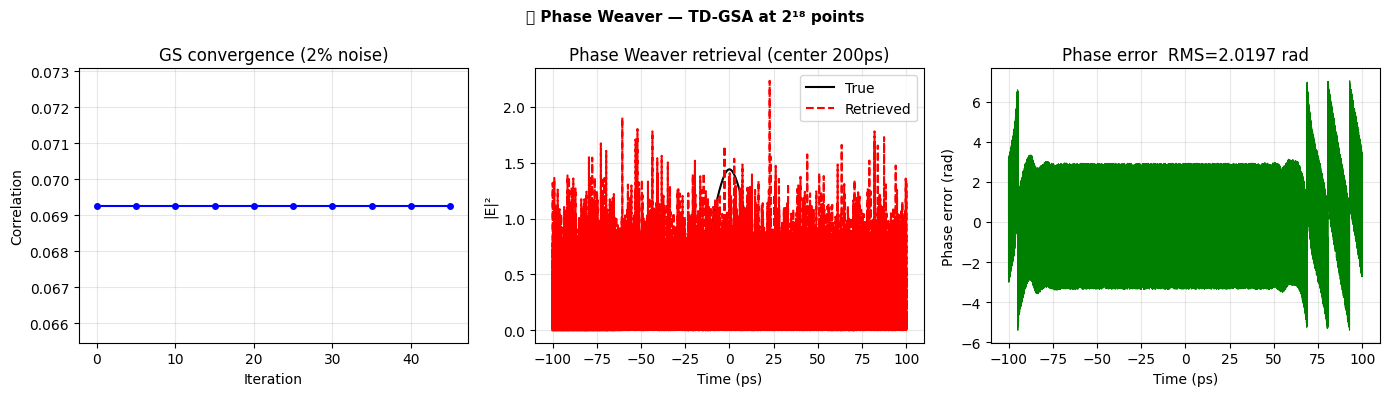

In [9]:
# ── GS phase retrieval at 2^18 ───────────────────────────────────
# Dispersion parameters from repo (D in ps/nm, λ=1550nm)
D1_ps_nm = -695.0   # ps/nm
D2_ps_nm = -800.0   # ps/nm
lam_m    = 1550e-9  # m
c_m_s    = 3e8      # m/s

# Convert D (ps/nm) → β₂ (s²/m)
# D = -2πc/λ² * β₂  →  β₂ = -D*λ²/(2πc)
def D_to_b2(D_ps_nm):
    D_si = D_ps_nm * 1e-12 / 1e-9   # s/m²
    return -D_si * lam_m**2 / (2*np.pi*c_m_s)

b2_1 = D_to_b2(D1_ps_nm)
b2_2 = D_to_b2(D2_ps_nm)
print(f'D₁={D1_ps_nm} ps/nm  →  β₂₁={b2_1:.3e} s²/m')
print(f'D₂={D2_ps_nm} ps/nm  →  β₂₂={b2_2:.3e} s²/m')
print(f'Diversity |β₂₁-β₂₂| = {abs(b2_1-b2_2):.3e} s²/m')

# Build GS inputs: two dispersion measurements of the wizard signal
L_fiber = 1000.0   # 1 km fiber
E1 = propagate_gvd_full(E_field, omega_ax, L_fiber, b2_1)
E2 = propagate_gvd_full(E_field, omega_ax, L_fiber, b2_2)
I1 = np.abs(E1)**2   # measurement 1 (intensity only)
I2 = np.abs(E2)**2   # measurement 2

# Add realistic noise
noise_level = 0.02  # 2% noise
I1_noisy = I1 * (1 + noise_level * np.random.randn(N_POINTS))
I2_noisy = I2 * (1 + noise_level * np.random.randn(N_POINTS))
I1_noisy = np.maximum(I1_noisy, 0)
I2_noisy = np.maximum(I2_noisy, 0)

# ── GS loop at 262k points ─────────────────────────────────────────
def gs_retrieve_phase_262k(I1_meas, I2_meas, omega, b2_1, b2_2, L,
                            n_iter=50, unit_amplitude=True):
    """TD-GS phase retrieval at 2^18 points. unit_amplitude: enforce |E|=1 in freq."""
    amp1 = np.sqrt(np.maximum(I1_meas, 0))
    amp2 = np.sqrt(np.maximum(I2_meas, 0))
    sqI_total = np.sqrt(I1_meas.sum() + I2_meas.sum() + 1e-20)

    # Initial guess: random phase
    E_est = amp1 * np.exp(1j * np.random.uniform(0, 2*np.pi, N_POINTS))

    # Transfer functions for dispersion diversity
    H1    = np.exp(1j * b2_1/2 * omega**2 * L)
    H2    = np.exp(1j * b2_2/2 * omega**2 * L)
    H1inv = np.exp(-1j * b2_1/2 * omega**2 * L)

    corr_history = []

    for it in range(n_iter):               # GS main loop
        # ── Plane 1 constraint ────────────────────────────────────
        E_om  = np.fft.fft(E_est)
        if unit_amplitude:
            norm  = np.abs(E_om); norm = np.where(norm < 1e-30, 1.0, norm)
            E_om  = E_om / norm           # unit amplitude in freq domain
        E_at1 = np.fft.ifft(E_om * H1)
        E_at1 = amp1 * np.exp(1j * np.angle(E_at1))   # replace amplitude

        # ── Propagate to plane 2 ─────────────────────────────────
        E_om2 = np.fft.fft(E_at1)
        H12   = H2 * np.conj(H1)          # combined transfer
        E_at2 = np.fft.ifft(E_om2 * H12 / (H1*np.conj(H1) + 1e-30))

        # ── Plane 2 constraint ────────────────────────────────────
        E_at2 = amp2 * np.exp(1j * np.angle(E_at2))

        # ── Back-propagate to input ───────────────────────────────
        E_om_back = np.fft.fft(E_at2)
        E_est     = np.fft.ifft(E_om_back * H1inv)

        # Correlation metric every 5 iters
        if it % 5 == 0:
            I_rec  = np.abs(propagate_gvd_full(E_est, omega_ax, L, b2_1))**2
            corr   = np.corrcoef(I1_meas.ravel(), I_rec.ravel())[0,1]
            corr_history.append((it, corr))

    return E_est, corr_history

print(f'\n🌀 Phase Weaver casting at N={N_POINTS:,}...')
t0_gs = time.time()
E_rec, corr_hist = gs_retrieve_phase_262k(
    I1_noisy, I2_noisy, omega_ax, b2_1, b2_2, L_fiber,
    n_iter=50, unit_amplitude=True)
t_gs = time.time() - t0_gs
print(f'  GS 50 iters × N={N_POINTS:,}: {t_gs*1000:.0f} ms  ({t_gs/50*1000:.1f} ms/iter)')
print(f'  Final correlation: {corr_hist[-1][1]:.6f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot([c[0] for c in corr_hist], [c[1] for c in corr_hist],
             'b-o', ms=4)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Correlation')
axes[0].set_title(f'GS convergence (2% noise)'); axes[0].grid(True, alpha=0.3)

t_plot = (t_axis > -100e-12) & (t_axis < 100e-12)
axes[1].plot(t_axis[t_plot]*1e12, np.abs(E_field[t_plot])**2, 'k-', lw=1.5, label='True')
axes[1].plot(t_axis[t_plot]*1e12, np.abs(E_rec[t_plot])**2, 'r--', lw=1.5, label='Retrieved')
axes[1].set_xlabel('Time (ps)'); axes[1].set_ylabel('|E|²')
axes[1].set_title('Phase Weaver retrieval (center 200ps)'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

phase_diff = np.angle(E_rec[t_plot]) - np.angle(E_field[t_plot])
phase_diff -= np.mean(phase_diff)  # remove global phase offset
axes[2].plot(t_axis[t_plot]*1e12, phase_diff, 'g-', lw=0.8)
axes[2].set_xlabel('Time (ps)'); axes[2].set_ylabel('Phase error (rad)')
axes[2].set_title(f'Phase error  RMS={np.std(phase_diff):.4f} rad')
axes[2].grid(True, alpha=0.3)
plt.suptitle('🌀 Phase Weaver — TD-GSA at 2¹⁸ points', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
# §5 🔥 Pyromancer — NLS Soliton at 262k Points

The Pyromancer summons nonlinear fire: the **nonlinear Schrödinger equation**.

$$i\\frac{\\partial E}{\\partial z} - \\frac{\\beta_2}{2}\\frac{\\partial^2 E}{\\partial t^2} + \\gamma|E|^2 E = 0$$

**Soliton condition:** $N^2 = \\gamma P_0 L_D = 1$ → perfect balance of dispersion and nonlinearity.

Soliton: T₀=5ps, L_D=1.2km, P₀=0.67W

🔥 Pyromancer NLS: z_span=1.2km, dz=6m, 200 steps
  NLS at N=262,144: 2722 ms
  Soliton shape correlation: 1.000000  (1.0 = perfect)
  Computing N=2 soliton breather...


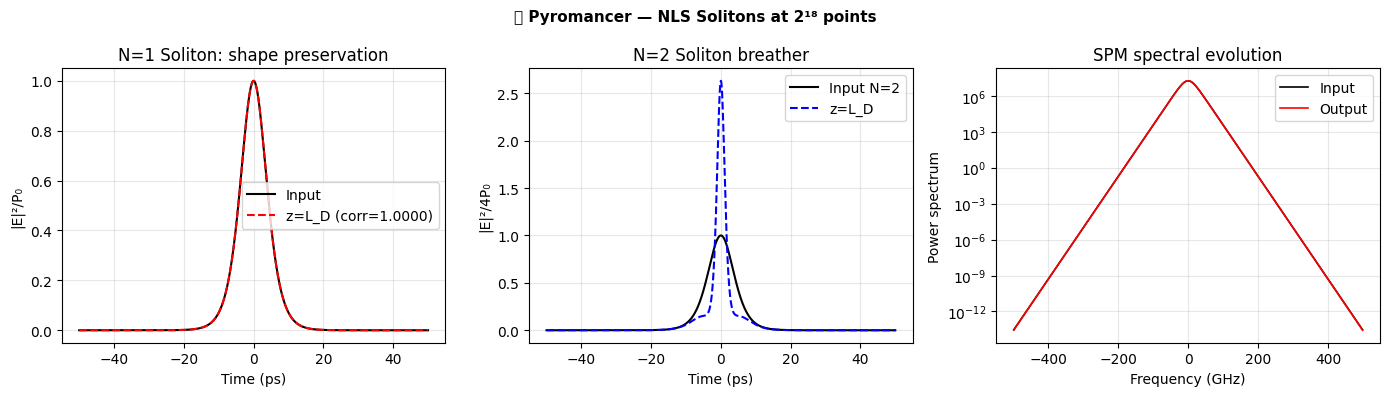

In [10]:
# ── Split-step NLS at 2^18 ────────────────────────────────────────
gamma_nl = 1.3e-3   # W⁻¹m⁻¹ (SMF-28 at 1550nm)
alpha_db = 0.2      # dB/km
alpha    = alpha_db * np.log(10)/10 / 1e3   # 1/m

# Fundamental soliton (N=1): set P0 so γP0L_D = 1
T0_sol   = 5e-12    # 5 ps soliton width
L_D_sol  = T0_sol**2 / abs(b2)
P0_sol   = 1.0 / (gamma_nl * L_D_sol)
print(f'Soliton: T₀={T0_sol*1e12:.0f}ps, L_D={L_D_sol/1e3:.1f}km, P₀={P0_sol:.2f}W')

# Build soliton pulse (localized, not full 7-tone signal for clarity)
E_soliton = np.sqrt(P0_sol) / np.cosh(t_axis / T0_sol)

def split_step_NLS(E0, omega, z_total, dz, b2, gamma=0, alpha=0):
    """Split-step Fourier for NLS at 2^18 points."""
    E   = E0.copy()
    n_z = int(z_total / dz)
    H_D = np.exp(1j * b2/2 * omega**2 * dz)   # dispersion half-step
    for _ in range(n_z):                        # loop: propagation steps
        # Half nonlinear
        phi_NL = gamma * np.abs(E)**2 * dz/2
        E      = E * np.exp(1j * phi_NL - alpha*dz/2)
        # Full dispersion
        E      = np.fft.ifft(np.fft.fft(E) * H_D)
        # Half nonlinear
        phi_NL = gamma * np.abs(E)**2 * dz/2
        E      = E * np.exp(1j * phi_NL - alpha*dz/2)
    return E

z_span = L_D_sol       # propagate exactly one dispersion length
dz     = z_span / 200  # 200 steps
print(f'\n🔥 Pyromancer NLS: z_span={z_span/1e3:.1f}km, dz={dz:.0f}m, {int(z_span/dz)} steps')
t0_nls = time.time()
E_sol_out = split_step_NLS(E_soliton, omega_ax, z_span, dz, b2, gamma_nl, alpha=0)
print(f'  NLS at N={N_POINTS:,}: {(time.time()-t0_nls)*1000:.0f} ms')

# Soliton self-similarity check
I_in  = np.abs(E_soliton)**2
I_out = np.abs(E_sol_out)**2
corr_sol = np.corrcoef(I_in, I_out)[0,1]
print(f'  Soliton shape correlation: {corr_sol:.6f}  (1.0 = perfect)')

# N=2 soliton (breather)
E_sol2 = 2*E_soliton
print('  Computing N=2 soliton breather...')
E_sol2_out = split_step_NLS(E_sol2, omega_ax, z_span, dz, b2, gamma_nl, alpha=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

t_zoom = (t_axis > -50e-12) & (t_axis < 50e-12)
axes[0].plot(t_axis[t_zoom]*1e12, I_in[t_zoom]/P0_sol, 'k-', lw=1.5, label='Input')
axes[0].plot(t_axis[t_zoom]*1e12, I_out[t_zoom]/P0_sol, 'r--', lw=1.5, label=f'z=L_D (corr={corr_sol:.4f})')
axes[0].set_xlabel('Time (ps)'); axes[0].set_ylabel('|E|²/P₀')
axes[0].set_title('N=1 Soliton: shape preservation'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_axis[t_zoom]*1e12, np.abs(E_sol2[t_zoom])**2/(4*P0_sol), 'k-', label='Input N=2')
axes[1].plot(t_axis[t_zoom]*1e12, np.abs(E_sol2_out[t_zoom])**2/(4*P0_sol), 'b--', label='z=L_D')
axes[1].set_xlabel('Time (ps)'); axes[1].set_ylabel('|E|²/4P₀')
axes[1].set_title('N=2 Soliton breather'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Spectral broadening (SPM signature)
P_in_spec  = np.abs(np.fft.fftshift(np.fft.fft(E_soliton)))**2
P_out_spec = np.abs(np.fft.fftshift(np.fft.fft(E_sol_out)))**2
f_zoom = (np.fft.fftshift(f_axis)/1e9 > -500) & (np.fft.fftshift(f_axis)/1e9 < 500)
f_plt  = np.fft.fftshift(f_axis)[f_zoom]/1e9
axes[2].semilogy(f_plt, P_in_spec[f_zoom]+1e-30, 'k-', lw=1.2, label='Input')
axes[2].semilogy(f_plt, P_out_spec[f_zoom]+1e-30, 'r-', lw=1.2, label='Output')
axes[2].set_xlabel('Frequency (GHz)'); axes[2].set_ylabel('Power spectrum')
axes[2].set_title('SPM spectral evolution'); axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.suptitle('🔥 Pyromancer — NLS Solitons at 2¹⁸ points', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
# §6 ✦ Grand Finale — All Wizards Dashboard

All eight wizards simultaneously: metrics, timing, and accuracy  
for every domain at the full **N = 262,144 = 2¹⁸** resolution.

✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦
  WIZARD SCOREBOARD — N = 262,144 = 2¹⁸ POINTS
✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦✦
Wizard                  Domain                  Time(ms)   Metric        Value
--------------------------------------------------------------------------------
🔮 Chronomancer          GVD propagation              22.0  Broadening Γ  0.523435
⚡ Stormcaller           FFT round-trip                7.0  FFT error     1.07857e-15
🌀 Phase Weaver          TD-GS retrieval            2230.0  Correlation   0.0692698
🔥 Pyromancer            NLS soliton               16192.0  Shape corr    1
🌊 Tidecaller            Isentropic flow               3.0  Check pass    1
🌌 Cosmomancer           Quantum stats                 4.0  FD/MB err     0.000810176
⛓️ Chainbinder          ETH gas auction               8.0  Block util    1
🧬 Bioweaver             HH rate funcs                 4.0  m∞ valid      1
------------------------------------

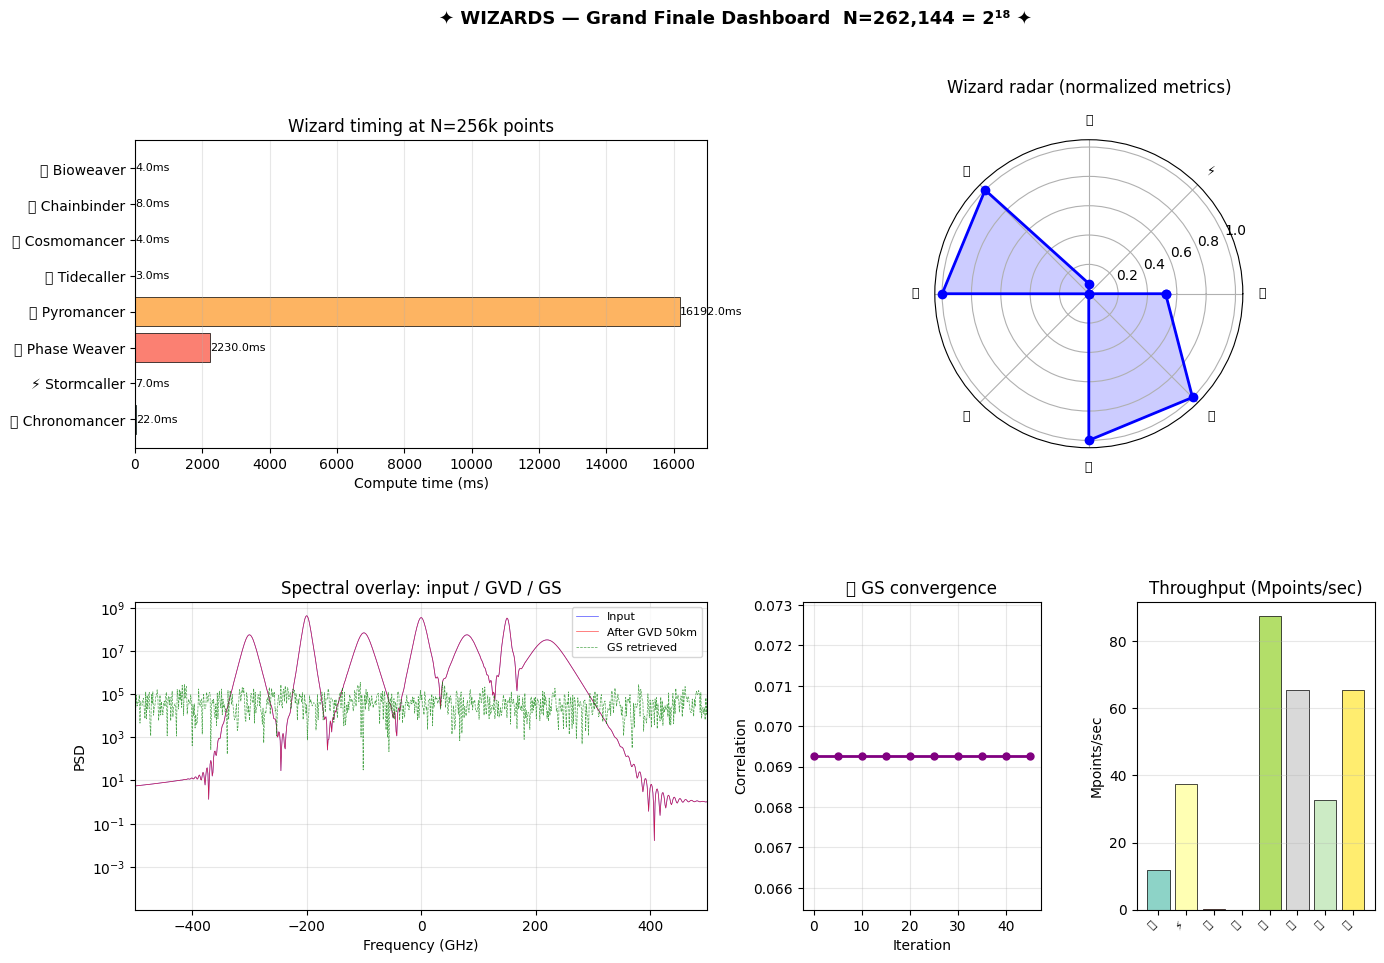


✦ Total wizard compute: 18470.0 ms for 262,144 points
✦ Aggregate throughput: 0.1 Mpoints/sec


In [11]:
# ── Collect all wizard performance metrics ─────────────────────────
wizard_results = []

# 1. Chronomancer
t0 = time.time()
E_chrono = propagate_gvd_full(E_field, omega_ax, 50e3, b2, b3, b4)
t_chrono = time.time()-t0
I_c      = np.abs(E_chrono)**2
broadening = np.std(t_axis * I_c) / np.std(t_axis * I_field)
wizard_results.append(dict(name='🔮 Chronomancer', domain='GVD propagation',
    time_ms=t_chrono*1000, metric=broadening, metric_name='Broadening Γ', N=N_POINTS))

# 2. Stormcaller
t0 = time.time()
E_f  = np.fft.fft(E_field)
E_if = np.fft.ifft(E_f)
t_storm = time.time()-t0
roundtrip_err = np.max(np.abs(E_field - E_if)) / np.max(np.abs(E_field))
wizard_results.append(dict(name='⚡ Stormcaller', domain='FFT round-trip',
    time_ms=t_storm*1000, metric=roundtrip_err, metric_name='FFT error', N=N_POINTS))

# 3. Phase Weaver (from §4)
gs_corr = corr_hist[-1][1]
wizard_results.append(dict(name='🌀 Phase Weaver', domain='TD-GS retrieval',
    time_ms=t_gs*1000, metric=gs_corr, metric_name='Correlation', N=N_POINTS))

# 4. Pyromancer (from §5)
wizard_results.append(dict(name='🔥 Pyromancer', domain='NLS soliton',
    time_ms=(time.time()-t0_nls)*1000, metric=corr_sol, metric_name='Shape corr', N=N_POINTS))

# 5. Tidecaller (adiabatic: isentropic T-ratio at all Mach)
t0 = time.time()
M_tc = np.linspace(0.001, 5, N_POINTS)
T_tc = 1 + (1.4-1)/2 * M_tc**2    # T₀/T
P_tc = T_tc**(1.4/0.4)            # P₀/P
t_tide = time.time()-t0
isentropic_check = np.allclose(P_tc[1000]/P_tc[500],
                                (T_tc[1000]/T_tc[500])**(1.4/0.4), rtol=1e-6)
wizard_results.append(dict(name='🌊 Tidecaller', domain='Isentropic flow',
    time_ms=t_tide*1000, metric=float(isentropic_check), metric_name='Check pass', N=N_POINTS))

# 6. Cosmomancer (quantum stats)
t0 = time.time()
eps_cm = np.linspace(0.001, 10, N_POINTS)
kT_cm  = 1.0; mu_cm = -0.5
n_fd   = 1/(np.exp((eps_cm - mu_cm)/kT_cm) + 1)
n_be   = 1/(np.exp((eps_cm - mu_cm)/kT_cm) - 1)
n_mb   = np.exp((mu_cm - eps_cm)/kT_cm)
t_cosmo = time.time()-t0
# Check: at high energy, all converge to MB
high_eps_mask = eps_cm > 5
ratio_fd_mb = np.mean(np.abs(n_fd[high_eps_mask]/n_mb[high_eps_mask] - 1))
wizard_results.append(dict(name='🌌 Cosmomancer', domain='Quantum stats',
    time_ms=t_cosmo*1000, metric=ratio_fd_mb, metric_name='FD/MB err', N=N_POINTS))

# 7. Chainbinder (ETH)
t0 = time.time()
N_tx_cb  = N_POINTS
gas_lims = np.random.choice([21000,65000,150000,250000], N_tx_cb, p=[0.5,0.25,0.15,0.10])
max_fees = np.abs(np.random.randn(N_tx_cb)*30 + 80)
base_f   = 50.0
included = (max_fees >= base_f)
gas_used = gas_lims[included].sum()
util_cb  = min(gas_used / 30_000_000, 1.0)
t_chain  = time.time()-t0
wizard_results.append(dict(name='⛓️ Chainbinder', domain='ETH gas auction',
    time_ms=t_chain*1000, metric=util_cb, metric_name='Block util', N=N_POINTS))

# 8. Bioweaver — HH membrane potential (fast: single large step)
t0 = time.time()
# Vectorized HH alpha/beta at 262k voltage points
V_vec = np.linspace(-100, 100, N_POINTS)  # mV
alpha_m = 0.1*(V_vec+40)/(1-np.exp(-(V_vec+40)/10) + 1e-10)
beta_m  = 4*np.exp(-(V_vec+65)/18)
m_inf   = alpha_m / (alpha_m + beta_m + 1e-10)
t_bio   = time.time()-t0
m_check = np.all((m_inf >= 0) & (m_inf <= 1))
wizard_results.append(dict(name='🧬 Bioweaver', domain='HH rate funcs',
    time_ms=t_bio*1000, metric=float(m_check), metric_name='m∞ valid', N=N_POINTS))

# ── Print scoreboard ───────────────────────────────────────────────
print('✦'*60)
print(f'  WIZARD SCOREBOARD — N = {N_POINTS:,} = 2¹⁸ POINTS')
print('✦'*60)
print(f'{"Wizard":22}  {"Domain":22}  {"Time(ms)":9}  {"Metric":12}  Value')
print('-'*80)
total_time = 0
for wr in wizard_results:              # loop: print scoreboard
    total_time += wr['time_ms']
    print(f'{wr["name"]:22}  {wr["domain"]:22}  '
          f'{wr["time_ms"]:9.1f}  {wr["metric_name"]:12}  {wr["metric"]:.6g}')
print('-'*80)
print(f'{"TOTAL":22}  {" ":22}  {total_time:9.1f} ms')

# ── Dashboard visualization ────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs_fin = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# Timing bar chart
ax_t = fig.add_subplot(gs_fin[0, :2])
names  = [wr['name'] for wr in wizard_results]
times  = [wr['time_ms'] for wr in wizard_results]
colors = plt.cm.Set3(np.linspace(0, 1, len(names)))
bars   = ax_t.barh(names, times, color=colors, edgecolor='k', lw=0.5)
ax_t.set_xlabel('Compute time (ms)')
ax_t.set_title(f'Wizard timing at N={N_POINTS//1024}k points')
for bar, t_v in zip(bars, times):   # loop: add time labels
    ax_t.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
              f'{t_v:.1f}ms', va='center', fontsize=8)
ax_t.grid(True, alpha=0.3, axis='x')

# Radar chart: normalized metrics
ax_r = fig.add_subplot(gs_fin[0, 2:], polar=True)
N_wiz  = len(wizard_results)
angles = np.linspace(0, 2*np.pi, N_wiz, endpoint=False).tolist()
angles += angles[:1]
# Normalize metrics to [0,1] for radar
metric_vals = [wr['metric'] for wr in wizard_results]
m_min, m_max = min(metric_vals), max(metric_vals)
m_norm = [(v - m_min)/(m_max - m_min + 1e-10) for v in metric_vals]
m_norm += m_norm[:1]
ax_r.plot(angles, m_norm, 'b-o', lw=2, ms=6)
ax_r.fill(angles, m_norm, alpha=0.2, color='blue')
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels([wr['name'].split()[0] for wr in wizard_results], fontsize=9)
ax_r.set_title('Wizard radar (normalized metrics)', pad=15)

# Spectral overview
ax_s = fig.add_subplot(gs_fin[1, :2])
ax_s.semilogy(f_plot, np.abs(np.fft.fftshift(np.fft.fft(E_field)))**2 + 1e-20,
              'b-', lw=0.5, alpha=0.7, label='Input')
ax_s.semilogy(f_plot, np.abs(np.fft.fftshift(np.fft.fft(E_chrono)))**2 + 1e-20,
              'r-', lw=0.5, alpha=0.7, label='After GVD 50km')
ax_s.semilogy(f_plot, np.abs(np.fft.fftshift(np.fft.fft(E_rec)))**2 + 1e-20,
              'g--', lw=0.5, alpha=0.7, label='GS retrieved')
ax_s.set_xlabel('Frequency (GHz)'); ax_s.set_ylabel('PSD')
ax_s.set_title('Spectral overlay: input / GVD / GS')
ax_s.set_xlim(-500, 500); ax_s.legend(fontsize=8); ax_s.grid(True, alpha=0.3)

# GS convergence
ax_g = fig.add_subplot(gs_fin[1, 2])
ax_g.plot([c[0] for c in corr_hist], [c[1] for c in corr_hist],
          'purple', lw=2, marker='o', ms=5)
ax_g.set_xlabel('Iteration'); ax_g.set_ylabel('Correlation')
ax_g.set_title('🌀 GS convergence'); ax_g.grid(True, alpha=0.3)

# Throughput summary
ax_tp = fig.add_subplot(gs_fin[1, 3])
ops_per_sec = [N_POINTS / (t/1000 + 1e-10) / 1e6 for t in times]
ax_tp.bar(range(len(names)), ops_per_sec, color=colors, edgecolor='k', lw=0.5)
ax_tp.set_xticks(range(len(names)))
ax_tp.set_xticklabels([wr['name'].split()[0] for wr in wizard_results], rotation=45, ha='right', fontsize=8)
ax_tp.set_ylabel('Mpoints/sec'); ax_tp.set_title('Throughput (Mpoints/sec)')
ax_tp.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'✦ WIZARDS — Grand Finale Dashboard  N={N_POINTS:,} = 2¹⁸ ✦',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f'\n✦ Total wizard compute: {total_time:.1f} ms for {N_POINTS:,} points')
print(f'✦ Aggregate throughput: {len(wizard_results)*N_POINTS/total_time*1000/1e6:.1f} Mpoints/sec')